In [3]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import re

df_sentences = pd.read_csv(r"C:\Users\13178\Downloads\cloud\sentences_for_testing.csv")

df_sentences


,id,sentence
0,1,The movie was amazing and inspiring.
1,2,The service was disappointing.
2,3,"It was okay, nothing special."
3,4,Absolutely loved the performance last night.
4,5,The instructions were confusing and frustrating.
5,6,The overall experience was fine.
6,7,I am not sure how I feel about it.
7,8,"The design is clean, but the build quality is ..."


In [6]:

def tokenize(s):
    return [t for t in re.sub(r"[^a-zA-Z0-9\s']", " ", s.lower()).split() if t]

vocab = sorted(set(tok for s in df_sentences['sentence'].tolist() for tok in tokenize(s)))
vocab_index = {w:i for i,w in enumerate(vocab)}

def bow_vector(s):
    import numpy as np
    v = np.zeros(len(vocab))
    for tok in tokenize(s):
        v[vocab_index[tok]] += 1.0
    n = np.linalg.norm(v)
    return v / n if n > 0 else v

X = np.vstack([bow_vector(s) for s in df_sentences['sentence']])
cosine_matrix = X @ X.T
cosine_df = pd.DataFrame(cosine_matrix,
                         index=[f"S{i}" for i in range(1, len(df_sentences)+1)],
                         columns=[f"S{i}" for i in range(1, len(df_sentences)+1)])
cosine_df.round(3)


,S1,S2,S3,S4,S5,S6,S7,S8
S1,1.000,0.408,0.183,0.167,0.333,0.365,0.000,0.218
S2,0.408,1.000,0.224,0.204,0.204,0.447,0.000,0.267
S3,0.183,0.224,1.000,0.000,0.000,0.200,0.135,0.000
S4,0.167,0.204,0.000,1.000,0.167,0.183,0.000,0.218
S5,0.333,0.204,0.000,0.167,1.000,0.183,0.000,0.218
S6,0.365,0.447,0.200,0.183,0.183,1.000,0.000,0.239
S7,0.000,0.000,0.135,0.000,0.000,0.000,1.000,0.000
S8,0.218,0.267,0.000,0.218,0.218,0.239,0.000,1.000


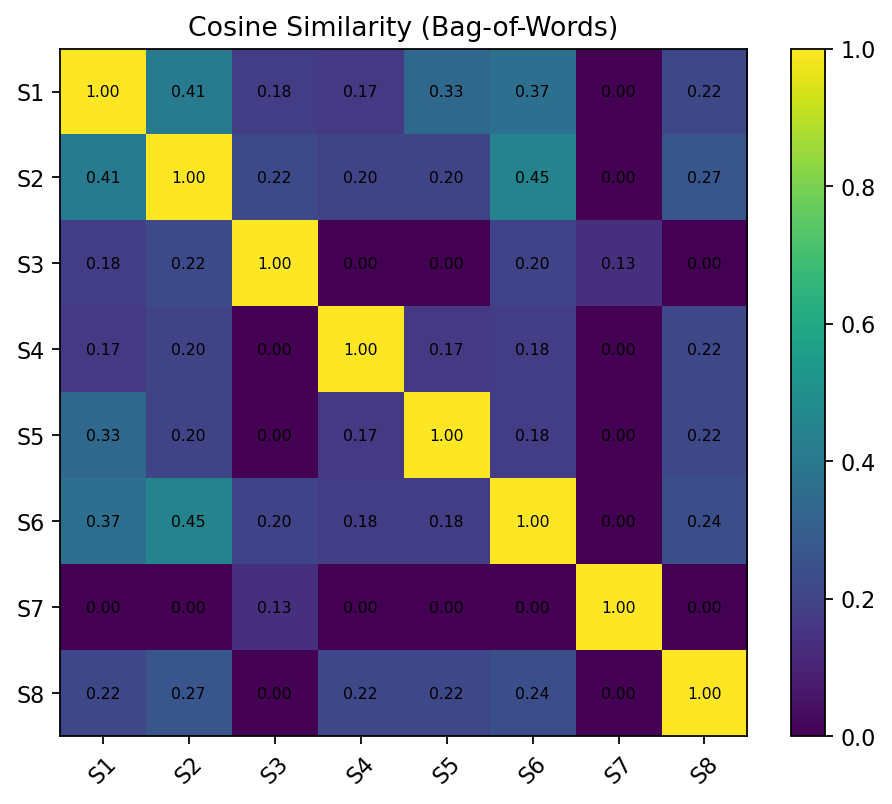

In [7]:

# Heatmap
plt.figure(figsize=(6,5), dpi=160)
plt.imshow(cosine_matrix, interpolation='nearest')
plt.title("Cosine Similarity (Bag-of-Words)")
plt.colorbar()
plt.xticks(range(len(df_sentences)), [f"S{i}" for i in range(1,len(df_sentences)+1)], rotation=45)
plt.yticks(range(len(df_sentences)), [f"S{i}" for i in range(1,len(df_sentences)+1)])
for (i,j), val in np.ndenumerate(cosine_matrix):
    plt.text(j, i, f"{val:.2f}", ha='center', va='center', fontsize=7)
plt.tight_layout()
plt.show()


In [5]:

api = pd.read_csv("cloud_sentiment_results_template.csv")
api.head()


,id,sentence,aws_label,aws_positive,aws_negative,aws_neutral,aws_mixed,Unnamed: 7,Unnamed: 8,azure_label,azure_positive,azure_neutral,azure_negative,notes
0,1,The movie was amazing and inspiring.,positive,0.99,0.00,0.00,0.00,NaN,NaN,positive,1.0,0.0,0.0,NaN
1,2,The service was disappointing.,negative,0.00,0.99,0.00,0.00,NaN,NaN,negative,0.0,0.0,1.0,NaN
2,3,"It was okay, nothing special.",mixed,0.00,0.00,0.02,0.96,NaN,NaN,neutral,0.0,1.0,0.0,NaN
3,4,Absolutely loved the performance last night.,positive,0.99,0.00,0.00,0.00,NaN,NaN,positive,1.0,0.0,0.0,NaN
4,5,The instructions were confusing and frustrating.,negative,0.00,0.99,0.00,0.00,NaN,NaN,negative,0.0,0.0,1.0,NaN


In [10]:

import numpy as np

def to_float(x):
    try:
        return float(x)
    except:
        return np.nan

aws_pos = api['aws_positive'].apply(to_float)
aws_neg = api['aws_negative'].apply(to_float)
aws_neu = api['aws_neutral'].apply(to_float)

azure_pos = api['azure_positive'].apply(to_float)
azure_neg = api['azure_negative'].apply(to_float)
azure_neu = api['azure_neutral'].apply(to_float)



aws_score_norm = aws_pos.fillna(0) - aws_neg.fillna(0)
aws_score_norm = aws_score_norm.where(~(aws_neu > aws_pos) & ~(aws_neu > aws_neg), 0.0)

azure_score_norm = azure_pos.fillna(0) - azure_neg.fillna(0)
azure_score_norm = azure_score_norm.where(~(azure_neu > azure_pos) & ~(azure_neu > azure_neg), 0.0)

comparison = pd.DataFrame({
    "id": api["id"],
    "sentence": api["sentence"],
    "aws_norm": aws_score_norm,
    
    "azure_norm": azure_score_norm
})
comparison


,id,sentence,aws_norm,azure_norm
0,1,The movie was amazing and inspiring.,0.99,1.0
1,2,The service was disappointing.,-0.99,-1.0
2,3,"It was okay, nothing special.",0.00,0.0
3,4,Absolutely loved the performance last night.,0.99,1.0
4,5,The instructions were confusing and frustrating.,-0.99,-1.0
5,6,The overall experience was fine.,0.97,0.0
6,7,I am not sure how I feel about it.,0.00,0.0
7,8,"The design is clean, but the build quality is ...",0.00,0.0


In [12]:

positive_words = {"amazing","inspiring","loved","clean","fine"}
negative_words = {"slow","disappointing","confusing","frustrating","cheap","terrible"}

axis = np.zeros(len(vocab))
for i,w in enumerate(vocab):
    if w in positive_words:
        axis[i] = 1.0
    elif w in negative_words:
        axis[i] = -1.0

axis_norm = axis / (np.linalg.norm(axis) if np.linalg.norm(axis)>0 else 1.0)
polarity = X @ axis_norm
if np.max(np.abs(polarity)) > 0:
    polarity = polarity / np.max(np.abs(polarity))

comparison["baseline_polarity"] = polarity

corr = comparison[["baseline_polarity","aws_norm","azure_norm"]].corr()
corr


,baseline_polarity,aws_norm,azure_norm
baseline_polarity,1.000000,0.959544,0.913618
aws_norm,0.959544,1.000000,0.909091
azure_norm,0.913618,0.909091,1.000000


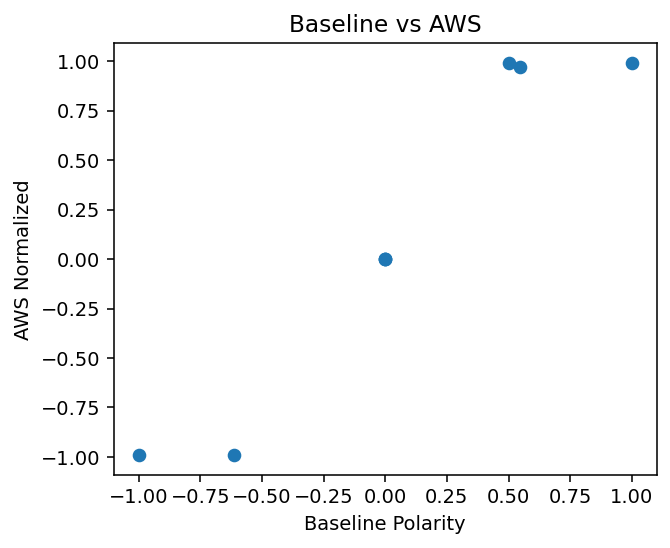

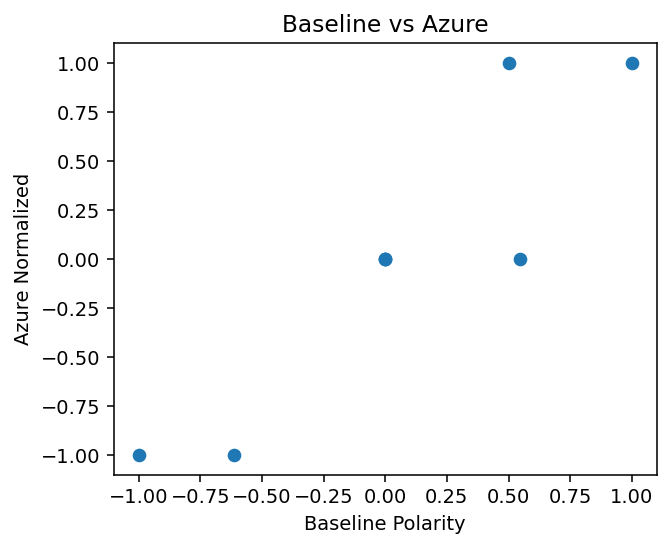

In [14]:

plt.figure(figsize=(5,4), dpi=140)
plt.scatter(comparison["baseline_polarity"], comparison["aws_norm"])
plt.xlabel("Baseline Polarity")
plt.ylabel("AWS Normalized")
plt.title("Baseline vs AWS")
plt.show()


plt.figure(figsize=(5,4), dpi=140)
plt.scatter(comparison["baseline_polarity"], comparison["azure_norm"])
plt.xlabel("Baseline Polarity")
plt.ylabel("Azure Normalized")
plt.title("Baseline vs Azure")
plt.show()
